In [133]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Ex1

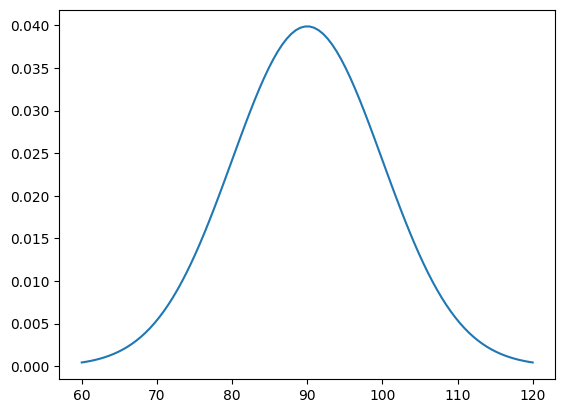

In [134]:
miu = 90
sigma = 10

x = np.linspace(miu - 3*sigma, miu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, miu, sigma))
plt.show()

# Ex2

In [135]:
def veros(x, miu, sigma):
    coef = 1/(np.sqrt(2*np.pi*(sigma**2)))
    frac = ((x - miu)**2)/(2*(sigma**2))
    exp = np.exp(-frac)
    return coef * exp

In [136]:
x1 = 82
rez_pdf = stats.norm.pdf(x1, miu, sigma)
print("Rez cu librarie")
print(rez_pdf)
rez_calc = veros(x1, miu, sigma)
print("Rez cu formula")
print(rez_calc)

Rez cu librarie
0.028969155276148274
Rez cu formula
0.028969155276148274


# Ex3

In [137]:
x = [82, 106, 120, 68, 83, 89, 130, 92, 99, 89]
rez_pdf = stats.norm.pdf(x, miu, sigma)
print("Rez cu librarie")
print(rez_pdf)
rez_calc = [veros(val, miu, sigma) for val in x]
print("Rez cu formula")
print(rez_calc)

Rez cu librarie
[2.89691553e-02 1.10920835e-02 4.43184841e-04 3.54745928e-03
 3.12253933e-02 3.96952547e-02 1.33830226e-05 3.91042694e-02
 2.66085250e-02 3.96952547e-02]
Rez cu formula
[0.028969155276148274, 0.011092083467945556, 0.0004431848411938007, 0.003547459284623144, 0.031225393336676125, 0.03969525474770118, 1.3383022576488536e-05, 0.039104269397545584, 0.02660852498987548, 0.03969525474770118]


# Ex4

In [138]:
medie = 100
dispersie = 50

In [139]:
def apriori(x):
    new_miu = np.random.normal(medie, dispersie)
    new_sigma = np.random.uniform(1, 70)

    return stats.norm.pdf(x, new_miu, new_sigma)

# Ex 5

In [140]:
apr = [apriori(val) for val in x]

verosim = [veros(val, miu, sigma) for val in x]

posteriori = [apr[i] * verosim[i] for i in range(len(x))]
print("Probabilitate a posteriori:")
print(posteriori)

Probabilitate a posteriori:
[0.0015039131585987053, 9.639910513711113e-05, 2.534044152048846e-31, 9.21264420375055e-06, 2.6827897604290408e-08, 9.649537781871858e-11, 1.7740331868528944e-08, 0.0002531477304882802, 3.6476762191918226e-07, 3.355998012995802e-05]


# Ex 6

In [141]:
mius = [70, 75, 80, 85, 90, 95, 100]
sigmas = [5, 10, 15, 20]

posteriori_models = []
for m in mius:
    for s in sigmas:
        verosim = np.prod([veros(xi, m, s) for xi in x])
        
        prior_miu = stats.norm.pdf(m, medie, dispersie)
        prior_sigma = stats.uniform.pdf(s, 1, 70)
        
        posterior = verosim * prior_miu * prior_sigma
        posteriori_models.append(posterior)

posteriori_models

[1.6741206834575846e-100,
 6.225854344888605e-40,
 6.419368684901517e-30,
 4.776139874277243e-27,
 3.0605241815490673e-80,
 7.544246442297135e-35,
 1.2024273146544823e-27,
 9.286368475592181e-26,
 2.51487905906623e-64,
 7.429398056308394e-31,
 7.340623978072014e-26,
 9.568366264061053e-25,
 9.2886078936616e-53,
 5.9458265968808415e-28,
 1.4605443653644655e-24,
 5.224595526134173e-24,
 1.5420426716178088e-45,
 3.8671560851334e-26,
 9.471181517410294e-24,
 1.5117868424359776e-23,
 1.1506795359406963e-42,
 2.0440523471839174e-25,
 2.0017101776423225e-23,
 2.3182029397616533e-23,
 3.8594429310001725e-44,
 8.780377263007838e-26,
 1.3788145747687214e-23,
 1.8838024059676428e-23]

In [142]:
best_idx = np.argmax(posteriori_models)
best_miu = mius[best_idx // len(sigmas)]
best_sigma = sigmas[best_idx % len(sigmas)]

print(f"Model optim: miu = {best_miu}, sigma = {best_sigma}")

Model optim: miu = 95, sigma = 20
